In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
daily_returns = pd.read_csv("../data/processed/daily_returns.csv")

daily_returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-04,515.0971,-0.010306
1,100016,2022-01-05,521.7239,0.012865
2,100016,2022-01-06,515.7880,-0.011377
3,100016,2022-01-07,515.1639,-0.001210
4,100016,2022-01-10,510.7136,-0.008639


In [3]:
daily_returns["date"] = pd.to_datetime(daily_returns["date"])

daily_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45960 entries, 0 to 45959
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   amfi_code     45960 non-null  int64         
 1   date          45960 non-null  datetime64[ns]
 2   nav           45960 non-null  float64       
 3   daily_return  45960 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.4 MB


In [4]:
print("Total Records :", len(daily_returns))
print("Unique Funds :", daily_returns["amfi_code"].nunique())

daily_returns.describe()

Total Records : 45960
Unique Funds : 40


,amfi_code,date,nav,daily_return
count,45960.000000,45960,45960.000000,45960.000000
mean,120247.000000,2024-03-17 04:46:59.843341568,269.624535,0.000631
min,100016.000000,2022-01-04 00:00:00,26.136600,-0.058102
25%,118632.750000,2023-02-09 00:00:00,69.195975,-0.005042
50%,119551.500000,2024-03-18 00:00:00,122.802200,0.000340
75%,120842.250000,2025-04-23 00:00:00,260.426750,0.006324
max,149324.000000,2026-05-29 00:00:00,4268.549700,0.064713
std,14352.317357,NaN,577.252241,0.010290


In [5]:
# Calculate Historical VaR (95%)

var_results = []

for code, group in daily_returns.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)

    var_results.append({
        "amfi_code": code,
        "VaR_95": round(var_95, 6)
    })

var_df = pd.DataFrame(var_results)

print("Total Funds:", len(var_df))
var_df.head()

Total Funds: 40


,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [6]:
# Calculate Historical CVaR (95%)

cvar_results = []

for code, group in daily_returns.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[returns <= var_95].mean()

    cvar_results.append({
        "amfi_code": code,
        "CVaR_95": round(cvar_95, 6)
    })

cvar_df = pd.DataFrame(cvar_results)

print("Total Funds:", len(cvar_df))
cvar_df.head()

Total Funds: 40


,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [7]:
# Merge VaR and CVaR

var_cvar_df = pd.merge(
    var_df,
    cvar_df,
    on="amfi_code"
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
# Save VaR & CVaR Report

var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("Historical VaR & CVaR calculation completed successfully!")
print("Output File: data/processed/var_cvar_report.csv")

Historical VaR & CVaR calculation completed successfully!
Output File: data/processed/var_cvar_report.csv


In [9]:
# Sort the data

daily_returns = daily_returns.sort_values(
    ["amfi_code", "date"]
)

daily_returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-04,515.0971,-0.010306
1,100016,2022-01-05,521.7239,0.012865
2,100016,2022-01-06,515.7880,-0.011377
3,100016,2022-01-07,515.1639,-0.001210
4,100016,2022-01-10,510.7136,-0.008639


In [10]:
# Calculate Rolling Sharpe Ratio

rolling_list = []

for code, group in daily_returns.groupby("amfi_code"):

    group = group.copy()

    group["rolling_mean"] = (
        group["daily_return"]
        .rolling(window=90)
        .mean()
    )

    group["rolling_std"] = (
        group["daily_return"]
        .rolling(window=90)
        .std()
    )

    group["rolling_sharpe"] = (
        (group["rolling_mean"] / group["rolling_std"])
        * np.sqrt(252)
    )

    rolling_list.append(group)

rolling_df = pd.concat(
    rolling_list,
    ignore_index=True
)

rolling_df.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
1,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
2,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
3,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN
4,100016,2022-01-10,510.7136,-0.008639,NaN,NaN,NaN


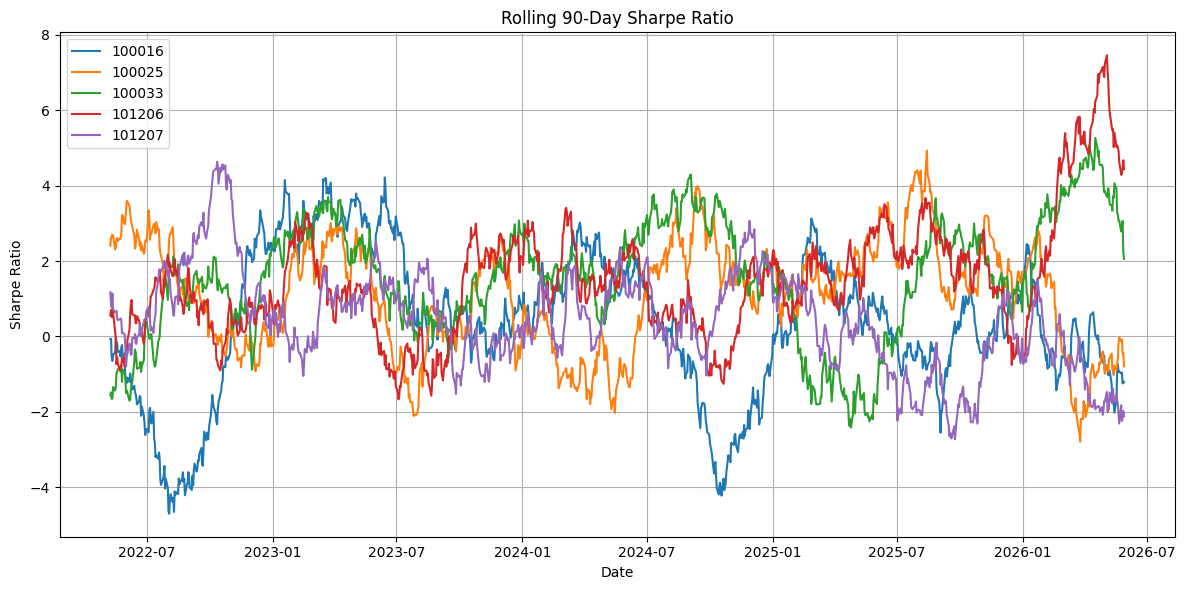

In [11]:
# Plot Rolling Sharpe Ratio

top5 = rolling_df["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for code in top5:

    temp = rolling_df[
        rolling_df["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

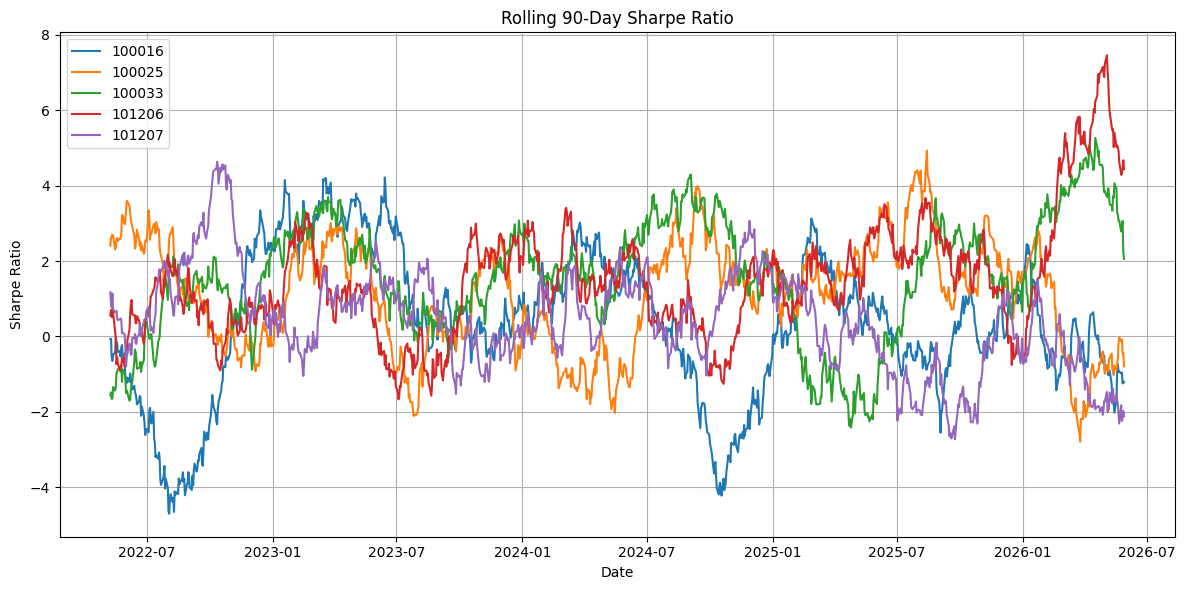

Rolling Sharpe Chart Saved Successfully!


In [12]:
# Save Chart

plt.figure(figsize=(12,6))

for code in top5:

    temp = rolling_df[
        rolling_df["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

print("Rolling Sharpe Chart Saved Successfully!")

In [13]:
investors = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [14]:
investors["transaction_date"] = pd.to_datetime(
    investors["transaction_date"]
)

investors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  object        
 1   transaction_date    32778 non-null  datetime64[ns]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  object        
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  object        
 6   city                32778 non-null  object        
 7   city_tier           32778 non-null  object        
 8   age_group           32778 non-null  object        
 9   gender              32778 non-null  object        
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  object        
 12  kyc_status          32778 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), ob

In [15]:
# Find first transaction year

first_year = (
    investors.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_year.columns = [
    "investor_id",
    "cohort_year"
]

first_year.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [16]:
investors = pd.merge(
    investors,
    first_year,
    on="investor_id"
)

investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [17]:
cohort_analysis = (
    investors
    .groupby("cohort_year")
    .agg(
        Average_Investment=("amount_inr", "mean"),
        Total_Investment=("amount_inr", "sum"),
        Total_Investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_analysis

,cohort_year,Average_Investment,Total_Investment,Total_Investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [19]:
# Top Preferred Fund for each Cohort

top_fund = (
    investors
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [20]:
# Merge Cohort Analysis with Top Fund

cohort_analysis = pd.merge(
    cohort_analysis,
    top_fund[["cohort_year", "amfi_code"]],
    on="cohort_year",
    how="left"
)

cohort_analysis.rename(
    columns={
        "amfi_code": "Top_Preferred_Fund"
    },
    inplace=True
)

cohort_analysis

,cohort_year,Average_Investment,Total_Investment,Total_Investors,Top_Preferred_Fund
0,2024,107422.541832,3491125187,4803,148568
1,2025,109158.577061,30455243,197,119599


In [21]:
print("Investor Cohort Analysis")

cohort_analysis

Investor Cohort Analysis


,cohort_year,Average_Investment,Total_Investment,Total_Investors,Top_Preferred_Fund
0,2024,107422.541832,3491125187,4803,148568
1,2025,109158.577061,30455243,197,119599


In [22]:
# Filter only SIP transactions

sip_df = investors[
    investors["transaction_type"] == "Sip"
].copy()

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [23]:
# Sort transactions

sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [24]:
# Calculate days between SIPs

sip_df["previous_date"] = (
    sip_df.groupby("investor_id")["transaction_date"]
    .shift(1)
)

sip_df["gap_days"] = (
    sip_df["transaction_date"] -
    sip_df["previous_date"]
).dt.days

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,previous_date,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaT,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,2024-11-04,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaT,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024-03-29,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,2024-09-21,238.0


In [25]:
# Investor Status

sip_df["status"] = np.where(
    sip_df["gap_days"] > 35,
    "At Risk",
    "Active"
)

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,previous_date,gap_days,status
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaT,NaN,Active
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,2024-11-04,76.0,At Risk
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaT,NaN,Active
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024-03-29,176.0,At Risk
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,2024-09-21,238.0,At Risk


In [26]:
# Summary

status_summary = (
    sip_df["status"]
    .value_counts()
    .reset_index()
)

status_summary.columns = [
    "Status",
    "Number_of_Transactions"
]

status_summary

,Status,Number_of_Transactions
0,At Risk,9913
1,Active,9803


In [27]:
# Save Report

sip_df.to_csv(
    "../data/processed/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved Successfully!")
print("Output File: data/processed/sip_continuity_report.csv")

SIP Continuity Report Saved Successfully!
Output File: data/processed/sip_continuity_report.csv


In [29]:
# Load Fund Scorecard

funds = pd.read_csv("../data/processed/fund_scorecard.csv")

funds.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,beta_x,sharpe_ratio_x,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,average_daily_return,std_deviation,sharpe_ratio_y,Rank,alpha_y,beta_y,r_squared,maximum_drawdown,worst_date,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High,0.001161,0.012152,1.1801,5,0.278249,0.0,0.0001,-18.19,2025-01-23,8.0,5.0,5.0,15.0,25.0,100.000000
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High,0.001082,0.010008,1.3067,2,0.260693,0.0,0.0001,-12.97,2022-04-13,11.0,2.0,7.0,22.0,13.0,98.734177
2,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,0.001074,0.008941,1.4483,1,0.278900,-0.0,0.0001,-11.27,2023-10-20,17.0,1.0,4.0,23.0,8.0,96.835443
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High,0.001080,0.011929,1.0937,7,0.265138,0.0,0.0000,-16.22,2022-05-12,10.0,7.0,6.0,17.0,20.0,96.518987
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,0.001201,0.015837,0.9453,14,0.295143,0.0,0.0000,-28.71,2025-05-14,1.0,14.0,3.0,21.0,36.0,94.462025


In [30]:
funds.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha_x',
 'beta_x',
 'sharpe_ratio_x',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade',
 'average_daily_return',
 'std_deviation',
 'sharpe_ratio_y',
 'Rank',
 'alpha_y',
 'beta_y',
 'r_squared',
 'maximum_drawdown',
 'worst_date',
 'return_rank',
 'sharpe_rank',
 'alpha_rank',
 'expense_rank',
 'drawdown_rank',
 'fund_score']

In [31]:
# Filter only Equity funds

equity_funds = funds[
    funds["category"].str.contains("Equity", case=False, na=False)
].copy()

# Calculate HHI

hhi_data = (
    equity_funds
    .groupby("category")["aum_crore"]
    .sum()
    .reset_index()
)

total_aum = hhi_data["aum_crore"].sum()

hhi_data["weight"] = hhi_data["aum_crore"] / total_aum
hhi_data["weight_sq"] = hhi_data["weight"] ** 2

HHI = hhi_data["weight_sq"].sum()

print("HHI:", round(HHI, 4))

hhi_data

HHI: 0.0


,category,aum_crore,weight,weight_sq


In [33]:
# HHI Calculation (AUM-based Approximation)

hhi_data = (
    funds
    .groupby("category")["aum_crore"]
    .sum()
    .reset_index()
)

total_aum = hhi_data["aum_crore"].sum()

hhi_data["weight"] = hhi_data["aum_crore"] / total_aum

hhi_data["weight_sq"] = hhi_data["weight"] ** 2

HHI = hhi_data["weight_sq"].sum()

print(f"Herfindahl-Hirschman Index (HHI): {HHI:.4f}")

hhi_data

Herfindahl-Hirschman Index (HHI): 0.1876


,category,aum_crore,weight,weight_sq
0,ELSS,2989,0.002864,0.000008
1,Flexi Cap,52924,0.050710,0.002571
2,Gilt,54131,0.051866,0.002690
3,Index,7350,0.007042,0.000050
4,Index/ETF,20284,0.019435,0.000378
5,Large & Mid Cap,49046,0.046994,0.002208
6,Large Cap,324466,0.310891,0.096653
7,Liquid,105734,0.101310,0.010264
8,Mid Cap,198984,0.190659,0.036351
9,Short Duration,27953,0.026784,0.000717


In [34]:
# Interpretation

if HHI < 0.15:
    print("Portfolio is well diversified.")

elif HHI < 0.25:
    print("Portfolio has moderate concentration.")

else:
    print("Portfolio is highly concentrated.")

Portfolio has moderate concentration.


In [35]:
# Save HHI Report

hhi_data.to_csv(
    "../data/processed/hhi_report.csv",
    index=False
)

print("HHI Report saved successfully!")

HHI Report saved successfully!


# Advanced Analytics Insights

# 1. Historical VaR and CVaR
Historical VaR and CVaR analysis measures the downside risk of each mutual fund and helps identify funds with higher potential losses during adverse market conditions.

# 2. Rolling 90-Day Sharpe Ratio
Rolling Sharpe Ratio shows that the risk-adjusted performance of mutual funds changes over time, indicating periods of stronger and weaker performance.

# 3. Investor Cohort Analysis
Investor cohorts based on their first investment year reveal differences in average investment amounts and preferred mutual funds.

# 4. SIP Continuity Analysis
Investors with SIP gaps greater than 35 days are classified as "At Risk," enabling fund houses to identify and engage investors who may discontinue systematic investments.

# 5. Fund Recommendation
The recommendation system suggests the top three mutual funds based on the investor's risk appetite using performance metrics such as Sharpe Ratio, Alpha, Drawdown, and long-term returns.